Manutencao preditiva de trocas de oleo
Esse notebook faz a limpeza dos dados, mostra os graficos de analise e testa uns modelos simples de previsao.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Carregando os dados

In [36]:
df = pd.read_csv('dataset.csv', parse_dates=['Data'], index_col='Data')
df = df.sort_index()
df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


Preenchendo os dias que faltam no dataset e os valores em branco

In [37]:
dias = pd.date_range(df.index.min(), df.index.max(), freq='D')
df = df.reindex(dias)
df.index.name = 'Data'

df['Trocas_Oleo'] = pd.to_numeric(df['Trocas_Oleo'], errors='coerce')
df['Trocas_Oleo'] = df['Trocas_Oleo'].interpolate().ffill().bfill().round()

df['Manutencao_Motor'] = pd.to_numeric(df['Manutencao_Motor'], errors='coerce')
df['Manutencao_Motor'] = df['Manutencao_Motor'].interpolate().ffill().bfill()

df.isna().sum()

,0
Trocas_Oleo,0
Manutencao_Motor,0


Tirando os outliers, tipo aquele dia com 500 trocas por erro de digitacao do mecanico. Usamos media + 3 desvios padrao como limite normal e cortamos quem passar disso.

In [38]:
media = df['Trocas_Oleo'].mean()
desvio = df['Trocas_Oleo'].std()
limite = round(media + 3 * desvio)
print('limite considerado normal:', limite)

df['Trocas_Oleo'] = df['Trocas_Oleo'].clip(upper=limite)

limite considerado normal: 61


Grafico da serie completa

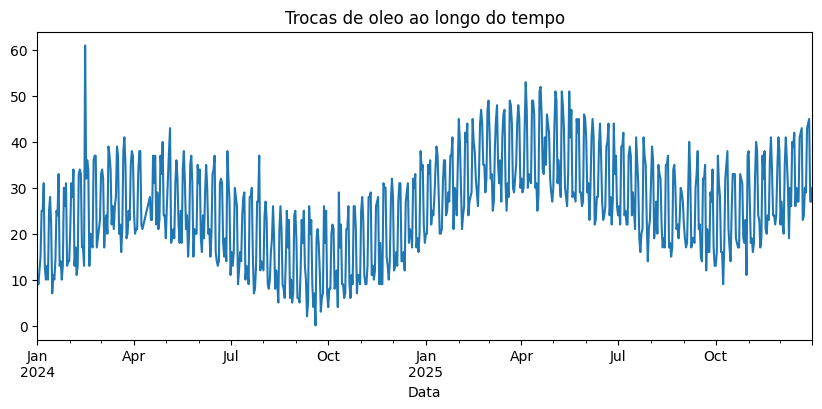

In [39]:
df['Trocas_Oleo'].plot(figsize=(10, 4), title='Trocas de oleo ao longo do tempo')
plt.show()

Separando a serie em tendencia, sazonalidade e ruido

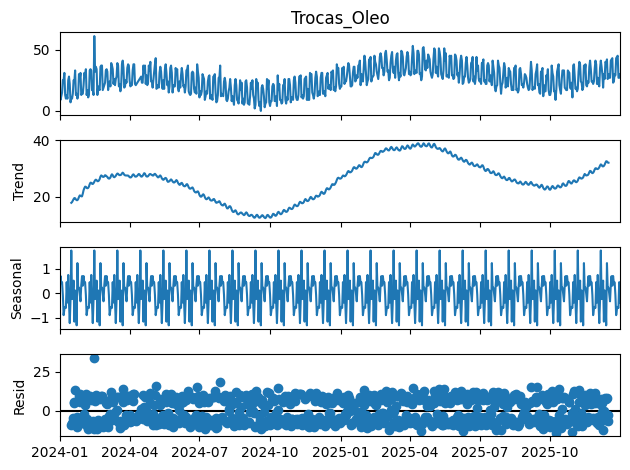

In [40]:
resultado = seasonal_decompose(df['Trocas_Oleo'], model='additive', period=30)
resultado.plot()
plt.show()

Para o modelo enxergar o passado, criamos atributos defasados "lags" e uma média móvel para usar como entrada

In [41]:
df['lag_1'] = df['Trocas_Oleo'].shift(1)
df['lag_7'] = df['Trocas_Oleo'].shift(7)
df['lag_30'] = df['Trocas_Oleo'].shift(30)

Criando a janela rolante sem vazar dados futuros

In [42]:
df['rolling_mean_7'] = df['Trocas_Oleo'].shift(1).rolling(7).mean()
df['rolling_mean_30'] = df['Trocas_Oleo'].shift(1).rolling(30).mean()

o TimeSeriesSplit mede a estabilidade do erro ao longo do tempo.

In [43]:
df['previsao_naive'] = df['lag_1']
df['previsao_naive_sazonal_7'] = df['lag_7']
df['previsao_naive_sazonal_30'] = df['lag_30']
df['media_movel_7'] = df['rolling_mean_7']
df['media_movel_30'] = df['rolling_mean_30']

Imports das bibliotecas de métricas

In [44]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

Tirando os valores nulos

In [45]:
df_limpo = df.dropna().copy()

y_real = df_limpo['Trocas_Oleo']
y_pred_naive = df_limpo['previsao_naive']
y_pred_naive_7 = df_limpo['previsao_naive_sazonal_7']
y_pred_naive_30 = df_limpo['previsao_naive_sazonal_30']
y_pred_mm7 = df_limpo['media_movel_7']
y_pred_mm30 = df_limpo['media_movel_30']

Conferindo se as features ficaram certas

In [46]:
df_limpo.head(15)

,Trocas_Oleo,Manutencao_Motor,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30,previsao_naive,previsao_naive_sazonal_7,previsao_naive_sazonal_30,media_movel_7,media_movel_30
Data,,,,,,,,,,,,
2024-01-31,14.0,5.0,14.0,10.0,11.0,19.571429,17.900000,14.0,10.0,11.0,19.571429,17.900000
2024-02-01,21.0,13.0,14.0,13.0,9.0,20.142857,18.000000,14.0,13.0,9.0,20.142857,18.000000
2024-02-02,31.0,12.0,21.0,30.0,12.0,21.285714,18.400000,21.0,30.0,12.0,21.285714,18.400000
2024-02-03,28.0,13.0,31.0,26.0,15.0,21.428571,19.033333,31.0,26.0,15.0,21.428571,19.033333
2024-02-04,34.0,12.0,28.0,31.0,25.0,21.714286,19.466667,28.0,31.0,25.0,21.714286,19.466667
2024-02-05,13.0,5.0,34.0,13.0,25.0,22.142857,19.766667,34.0,13.0,25.0,22.142857,19.766667
2024-02-06,17.0,10.0,13.0,14.0,31.0,22.142857,19.366667,13.0,14.0,31.0,22.142857,19.366667
2024-02-07,11.0,3.0,17.0,14.0,13.0,22.571429,18.900000,17.0,14.0,13.0,22.571429,18.900000
2024-02-08,13.0,8.0,11.0,21.0,10.0,22.142857,18.833333,11.0,21.0,10.0,22.142857,18.833333


Criando função avaliadora

In [47]:
def avaliar_modelo(y_true, y_pred, nome_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"Resultados do {nome_modelo} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

Rodando os baselines e o modelo de regressão com lags usando o TimeSeriesSplit.
E evitando que informação do período de teste influencie o ajuste do modelo.

In [48]:
tscv = TimeSeriesSplit(n_splits=3)

for i, (treino_index, teste_index) in enumerate(tscv.split(df_limpo), start=1):
  y_teste_real = y_real.iloc[teste_index]
  y_teste_naive = y_pred_naive.iloc[teste_index]
  y_teste_naive_7 = y_pred_naive_7.iloc[teste_index]
  y_teste_naive_30 = y_pred_naive_30.iloc[teste_index]
  y_teste_mm7 = y_pred_mm7.iloc[teste_index]
  y_teste_mm30 = y_pred_mm30.iloc[teste_index]

  print(f"\n Partição {i}")
  avaliar_modelo(y_teste_real, y_teste_naive, "Naive Simples")
  avaliar_modelo(y_teste_real, y_teste_naive_7, "Naive Sazonal Semanal")
  avaliar_modelo(y_teste_real, y_teste_naive_30, "Naive Sazonal Mensal")
  avaliar_modelo(y_teste_real, y_teste_mm7, "Média Móvel 7 Dias")
  avaliar_modelo(y_teste_real, y_teste_mm30, "Média Móvel 30 Dias")


 Partição 1
Resultados do Naive Simples - MAE: 6.57, RMSE: 8.89, MAPE: 18014398509482032.00%
Resultados do Naive Sazonal Semanal - MAE: 3.34, RMSE: 4.16, MAPE: 12867427506772874.00%
Resultados do Naive Sazonal Mensal - MAE: 10.31, RMSE: 12.44, MAPE: 20587884010836632.00%
Resultados do Média Móvel 7 Dias - MAE: 7.21, RMSE: 7.92, MAPE: 34558233875332844.00%
Resultados do Média Móvel 30 Dias - MAE: 7.13, RMSE: 8.04, MAPE: 34570488568196436.00%

 Partição 2
Resultados do Naive Simples - MAE: 6.69, RMSE: 8.85, MAPE: 19.90%
Resultados do Naive Sazonal Semanal - MAE: 3.75, RMSE: 4.63, MAPE: 11.41%
Resultados do Naive Sazonal Mensal - MAE: 10.62, RMSE: 12.78, MAPE: 31.20%
Resultados do Média Móvel 7 Dias - MAE: 7.42, RMSE: 8.18, MAPE: 22.15%
Resultados do Média Móvel 30 Dias - MAE: 7.41, RMSE: 8.22, MAPE: 22.04%

 Partição 3
Resultados do Naive Simples - MAE: 6.56, RMSE: 8.90, MAPE: 26.76%
Resultados do Naive Sazonal Semanal - MAE: 3.55, RMSE: 4.45, MAPE: 14.99%
Resultados do Naive Sazonal Me

Avaliação geral, considerando toda a série de uma vez

In [49]:
print("\nDesempenho Geral dos Baselines:")
avaliar_modelo(y_real, y_pred_naive, "Naive (Lag 1)")
avaliar_modelo(y_real, y_pred_naive_7, "Naive Sazonal Semanal (Lag 7)")
avaliar_modelo(y_real, y_pred_naive_30, "Naive Sazonal Mensal (Lag 30)")
avaliar_modelo(y_real, y_pred_mm7, "Média Móvel 7 Dias")
avaliar_modelo(y_real, y_pred_mm30, "Média Móvel 30 Dias")


Desempenho Geral dos Baselines:
Resultados do Naive (Lag 1) - MAE: 6.67, RMSE: 9.11, MAPE: 4497175091525490.50%
Resultados do Naive Sazonal Semanal (Lag 7) - MAE: 3.67, RMSE: 5.07, MAPE: 3212267922518203.00%
Resultados do Naive Sazonal Mensal (Lag 30) - MAE: 10.54, RMSE: 12.74, MAPE: 5139628676029146.00%
Resultados do Média Móvel 7 Dias - MAE: 7.38, RMSE: 8.21, MAPE: 8627233849048878.00%
Resultados do Média Móvel 30 Dias - MAE: 7.33, RMSE: 8.26, MAPE: 8630293151832227.00%


Comparando o valor real com as previsoes dos modelos baseline

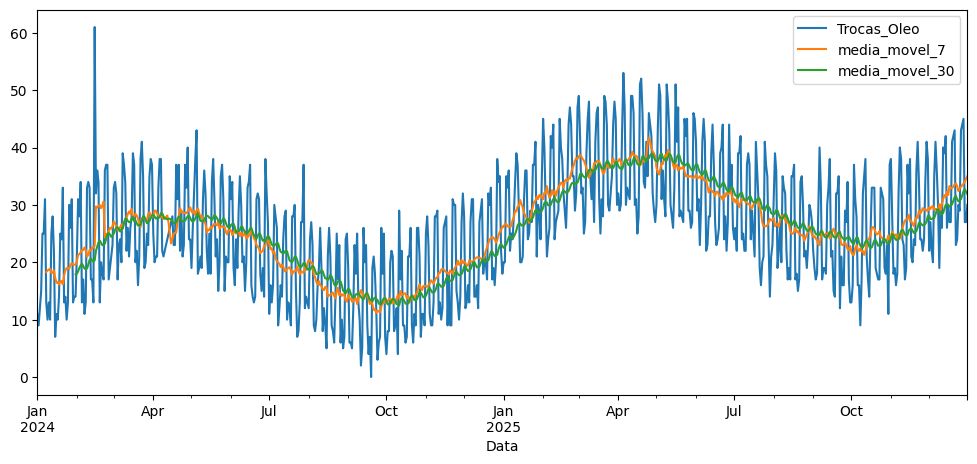

In [50]:
df[['Trocas_Oleo', 'media_movel_7', 'media_movel_30']].plot(figsize=(12, 5))
plt.show()